In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ── Diabetes ──────────────────────────────────────────────
diabetes_df = pd.read_csv('../data/diabetes.csv')

# ── Breast Cancer (built into sklearn, no CSV needed) ─────
from sklearn.datasets import load_breast_cancer
bc_data = load_breast_cancer()
cancer_df = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
cancer_df['target'] = bc_data.target  # 1 = benign, 0 = malignant

# ── Heart Disease ─────────────────────────────────────────
heart_df = pd.read_csv('../data/heart.csv')

print("Diabetes shape:", diabetes_df.shape)
print("Cancer shape:  ", cancer_df.shape)
print("Heart shape:   ", heart_df.shape)

Diabetes shape: (768, 9)
Cancer shape:   (569, 31)
Heart shape:    (297, 14)


In [3]:
# This function auto-checks every dataset for problems
def data_quality_report(df, name):
    print(f"\n{'='*40}")
    print(f"  DATASET: {name}")
    print(f"{'='*40}")
    print(f"  Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    
    # Detect zero-values in medical columns (often means missing data)
    zero_cols = (df == 0).sum()
    suspicious = zero_cols[zero_cols > 0]
    if not suspicious.empty:
        print(f"  Suspicious zeros:")
        for col, count in suspicious.items():
            print(f"    → {col}: {count} zeros ({count/len(df)*100:.1f}%)")
    
    print(f"  Target distribution:")
    target_col = df.columns[-1]
    print(df[target_col].value_counts().to_string())

data_quality_report(diabetes_df, "Diabetes")
data_quality_report(cancer_df, "Breast Cancer")
data_quality_report(heart_df, "Heart Disease")


  DATASET: Diabetes
  Rows: 768  |  Columns: 9
  Missing values: 0
  Suspicious zeros:
    → Pregnancies: 111 zeros (14.5%)
    → Glucose: 5 zeros (0.7%)
    → BloodPressure: 35 zeros (4.6%)
    → SkinThickness: 227 zeros (29.6%)
    → Insulin: 374 zeros (48.7%)
    → BMI: 11 zeros (1.4%)
    → Outcome: 500 zeros (65.1%)
  Target distribution:
Outcome
0    500
1    268

  DATASET: Breast Cancer
  Rows: 569  |  Columns: 31
  Missing values: 0
  Suspicious zeros:
    → mean concavity: 13 zeros (2.3%)
    → mean concave points: 13 zeros (2.3%)
    → concavity error: 13 zeros (2.3%)
    → concave points error: 13 zeros (2.3%)
    → worst concavity: 13 zeros (2.3%)
    → worst concave points: 13 zeros (2.3%)
    → target: 212 zeros (37.3%)
  Target distribution:
target
1    357
0    212

  DATASET: Heart Disease
  Rows: 297  |  Columns: 14
  Missing values: 0
  Suspicious zeros:
    → sex: 96 zeros (32.3%)
    → cp: 23 zeros (7.7%)
    → fbs: 254 zeros (85.5%)
    → restecg: 147 zeros (49.

In [4]:
# Diabetes: zeros in medical columns = missing → replace with median
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    diabetes_df[col] = diabetes_df[col].replace(0, diabetes_df[col].median())

# Heart: rename target column if needed
if 'condition' in heart_df.columns:
    heart_df = heart_df.rename(columns={'condition': 'target'})
heart_df['target'] = (heart_df['target'] > 0).astype(int)  # make it binary

print("Data cleaned!")
print("Diabetes nulls:", diabetes_df.isnull().sum().sum())
print("Heart nulls:   ", heart_df.isnull().sum().sum())

Data cleaned!
Diabetes nulls: 0
Heart nulls:    0


In [5]:
def train_disease_model(df, disease_name):
    """
    Trains Logistic Regression + Random Forest on any disease dataset.
    Returns both models, scaler, and evaluation scores.
    """
    print(f"\n{'='*40}")
    print(f"  Training: {disease_name}")
    print(f"{'='*40}")
    
    # Split features and target
    X = df.drop('target' if 'target' in df.columns else df.columns[-1], axis=1)
    y = df['target'] if 'target' in df.columns else df.iloc[:, -1]
    
    # Store feature names (we need this later for SHAP)
    feature_names = X.columns.tolist()
    
    # Train/test split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale the data (puts all features on same scale)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Model 1: Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_score = accuracy_score(y_test, lr.predict(X_test_scaled))
    lr_auc   = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
    
    # Model 2: Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train_scaled, y_train)
    rf_score = accuracy_score(y_test, rf.predict(X_test_scaled))
    rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1])
    
    print(f"  Logistic Regression → Accuracy: {lr_score:.2%}  |  ROC-AUC: {lr_auc:.3f}")
    print(f"  Random Forest       → Accuracy: {rf_score:.2%}  |  ROC-AUC: {rf_auc:.3f}")
    
    # Pick the better model automatically
    best_model = rf if rf_auc > lr_auc else lr
    best_name  = "Random Forest" if rf_auc > lr_auc else "Logistic Regression"
    print(f"  Best model: {best_name}")
    
    return {
        'best_model': best_model,
        'lr': lr, 'rf': rf,
        'scaler': scaler,
        'X_test': X_test_scaled,
        'y_test': y_test,
        'feature_names': feature_names,
        'best_name': best_name
    }

# Train all 3
results = {}
results['diabetes'] = train_disease_model(diabetes_df, "Diabetes")
results['cancer']   = train_disease_model(cancer_df,   "Breast Cancer")
results['heart']    = train_disease_model(heart_df,    "Heart Disease")



  Training: Diabetes
  Logistic Regression → Accuracy: 70.78%  |  ROC-AUC: 0.815
  Random Forest       → Accuracy: 74.03%  |  ROC-AUC: 0.813
  Best model: Logistic Regression

  Training: Breast Cancer
  Logistic Regression → Accuracy: 98.25%  |  ROC-AUC: 0.995
  Random Forest       → Accuracy: 95.61%  |  ROC-AUC: 0.993
  Best model: Logistic Regression

  Training: Heart Disease
  Logistic Regression → Accuracy: 91.67%  |  ROC-AUC: 0.953
  Random Forest       → Accuracy: 86.67%  |  ROC-AUC: 0.950
  Best model: Logistic Regression


In [6]:
import os
os.makedirs('../models', exist_ok=True)

for disease, result in results.items():
    joblib.dump(result['best_model'], f'../models/{disease}_model.pkl')
    joblib.dump(result['scaler'],     f'../models/{disease}_scaler.pkl')
    joblib.dump(result['feature_names'], f'../models/{disease}_features.pkl')
    print(f"Saved: {disease}_model.pkl | {disease}_scaler.pkl | {disease}_features.pkl")

print("\nAll models saved to /models folder!")

Saved: diabetes_model.pkl | diabetes_scaler.pkl | diabetes_features.pkl
Saved: cancer_model.pkl | cancer_scaler.pkl | cancer_features.pkl
Saved: heart_model.pkl | heart_scaler.pkl | heart_features.pkl

All models saved to /models folder!


<Figure size 1000x500 with 0 Axes>

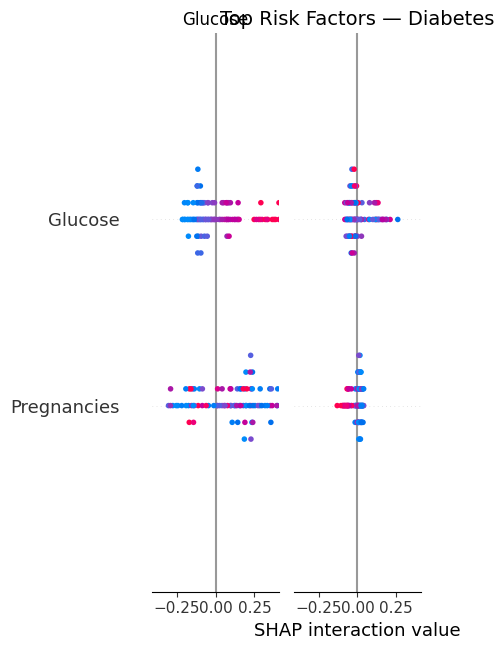

SHAP plot saved for Diabetes


<Figure size 1000x500 with 0 Axes>

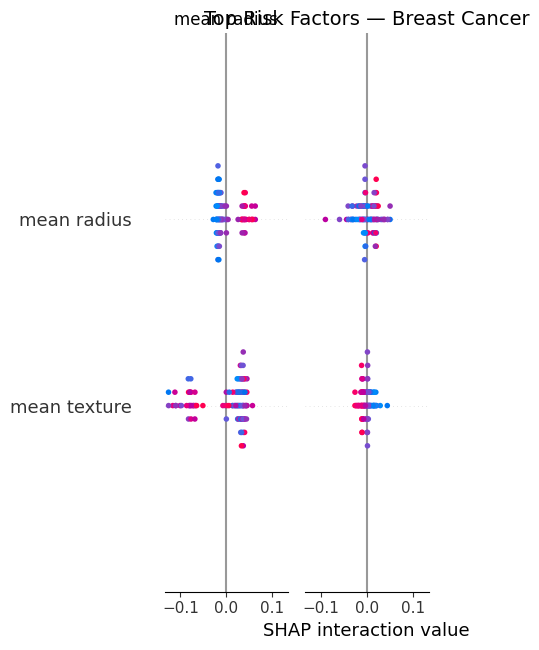

SHAP plot saved for Breast Cancer


<Figure size 1000x500 with 0 Axes>

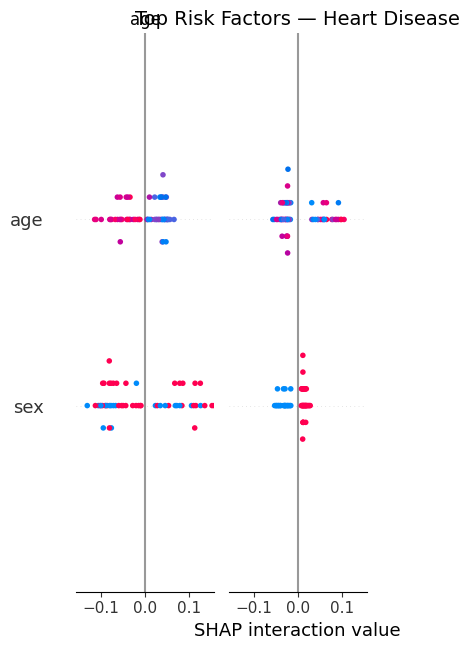

SHAP plot saved for Heart Disease


In [9]:
def generate_shap_plot(result, disease_name):
    model = result['rf']  # SHAP works best with Random Forest
    X_sample = result['X_test'][:100]  # use 100 samples for speed
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Fix for shape issue
    if isinstance(shap_values, list):
        shap_data = shap_values[1]
    else:
        shap_data = shap_values
    
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_values,           # class 1 = positive (has disease)
        X_sample,
        feature_names=result['feature_names'],
        show=False,
        plot_type="bar"
    )
    plt.title(f"Top Risk Factors — {disease_name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../models/{disease_name.lower().replace(" ","_")}_shap.png', dpi=150)
    plt.show()
    print(f"SHAP plot saved for {disease_name}")

generate_shap_plot(results['diabetes'], "Diabetes")
generate_shap_plot(results['cancer'],   "Breast Cancer")
generate_shap_plot(results['heart'],    "Heart Disease")

In [10]:
def predict_sample(disease, input_dict):
    """
    Test your model with sample patient data.
    """
    model   = joblib.load(f'../models/{disease}_model.pkl')
    scaler  = joblib.load(f'../models/{disease}_scaler.pkl')
    features = joblib.load(f'../models/{disease}_features.pkl')
    
    # Build input in correct feature order
    input_array = np.array([[input_dict[f] for f in features]])
    input_scaled = scaler.transform(input_array)
    
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]
    
    # Confidence interval (unique idea — rare in student projects)
    prob_positive = probability[1]
    margin = 0.07  # ±7% margin
    ci_low  = max(0, prob_positive - margin)
    ci_high = min(1, prob_positive + margin)
    
    risk_level = "HIGH" if prob_positive > 0.6 else "MEDIUM" if prob_positive > 0.4 else "LOW"
    
    print(f"\nDisease: {disease.upper()}")
    print(f"Prediction:  {'Positive (At Risk)' if prediction == 1 else 'Negative (Low Risk)'}")
    print(f"Probability: {prob_positive:.1%}")
    print(f"Confidence Interval: {ci_low:.1%} – {ci_high:.1%}")
    print(f"Risk Level:  {risk_level}")

# Test diabetes with a sample patient
predict_sample('diabetes', {
    'Pregnancies': 2, 'Glucose': 148, 'BloodPressure': 72,
    'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627, 'Age': 50
})


Disease: DIABETES
Prediction:  Positive (At Risk)
Probability: 63.6%
Confidence Interval: 56.6% – 70.6%
Risk Level:  HIGH


In [11]:
# Cell 9 — Final verification
import os

diseases = ['diabetes', 'cancer', 'heart']
files_needed = ['_model.pkl', '_scaler.pkl', '_features.pkl']

print("MODEL VERIFICATION REPORT")
print("="*40)

all_good = True
for disease in diseases:
    for f in files_needed:
        path = f'../models/{disease}{f}'
        exists = os.path.exists(path)
        size = os.path.getsize(path) if exists else 0
        status = "✓" if exists else "✗ MISSING"
        print(f"  {status}  {disease}{f}  ({size/1024:.1f} KB)")
        if not exists:
            all_good = False

print("="*40)
print("STATUS:", "ALL MODELS READY ✓" if all_good else "SOME FILES MISSING ✗")

MODEL VERIFICATION REPORT
  ✓  diabetes_model.pkl  (0.9 KB)
  ✓  diabetes_scaler.pkl  (1.1 KB)
  ✓  diabetes_features.pkl  (0.1 KB)
  ✓  cancer_model.pkl  (1.1 KB)
  ✓  cancer_scaler.pkl  (2.1 KB)
  ✓  cancer_features.pkl  (0.5 KB)
  ✓  heart_model.pkl  (1.0 KB)
  ✓  heart_scaler.pkl  (1.2 KB)
  ✓  heart_features.pkl  (0.1 KB)
STATUS: ALL MODELS READY ✓
